# Flux Comparison of HRDPS 1km, HRDPS 2.5km, HRDPS 10km and CaSR Outputs

## Load Data

In [ ]:
# Paths 

path_CaSR_flux='/ocean/jqiu/results/Flux/flux_01mar23_CaSR/SalishSea_1d_20230301_20230301_sbfx_T.nc'
path_HRDPS1_flux='/ocean/jqiu/results/Flux/flux_01mar23_hrdps1/SalishSea_1d_20230301_20230301_sbfx_T.nc'
path_HRDPS25_flux='/ocean/jqiu/results/Flux/flux_01mar23_hrdps2.5/SalishSea_1d_20230301_20230301_sbfx_T.nc'
path_HRDPS10_flux='/ocean/jqiu/results/Flux/flux_01mar23_hrdps10/SalishSea_1d_20230301_20230301_sbfx_T.nc'

# HRDPS 1 km flux NOT reliable! Don't use it yet!


In [ ]:
# load data and inspect variables

import xarray as xr

ds_CaSR_flux=xr.open_dataset(path_CaSR_flux)
# ds_HRDPS1_flux=xr.open_dataset(path_HRDPS1_flux)
ds_HRDPS25_flux=xr.open_dataset(path_HRDPS25_flux)
ds_HRDPS10_flux=xr.open_dataset(path_HRDPS10_flux)
# print(ds_CaSR_flux)

<xarray.Dataset> Size: 23MB
Dimensions:               (y: 898, x: 398, nvertex: 4, time_counter: 1,
                           axis_nbounds: 2)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
    time_centered         (time_counter) datetime64[ns] 8B ...
  * time_counter          (time_counter) datetime64[ns] 8B 2023-03-01T12:00:00
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 16B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 16B ...
    longwave_heat_flux    (time_counter, y, x) float32 1MB ...
    sensible_heat_flux    (time_counter, y, x) float32 1MB ...
    latent_heat_flux      (time_counter, y, x) float32 1MB ...
    emp_heat_flux


### Interesting variables

    longwave_heat_flux    (time_counter, y, x) float32 1MB ...
    sensible_heat_flux    (time_counter, y, x) float32 1MB ...
    latent_heat_flux      (time_counter, y, x) float32 1MB ...
    emp_heat_flux         (time_counter, y, x) float32 1MB ...
    wind_stress           (time_counter, y, x) float32 1MB ...

All the heat fluxes above are downward. Wind stress stands for magnitude of surface downward stress.

Total heat budget may require short wave radiation, which we don't have here. It's included in the forcing data.

In [7]:
for v in [
    "longwave_heat_flux",
    "sensible_heat_flux",
    "latent_heat_flux",
    "emp_heat_flux",
    "shortwave_heat_flux",
    "wind_stress",
]:
    if v in ds_CaSR_flux:
        print(v, ds_CaSR_flux[v].attrs)

longwave_heat_flux {'standard_name': 'surface_net_downward_longwave_flux', 'long_name': 'Longwave Downward Heat Flux over open ocean', 'units': 'W/m2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}
sensible_heat_flux {'standard_name': 'surface_downward_sensible_heat_flux', 'long_name': 'Sensible Downward Heat Flux over open ocean', 'units': 'W/m2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}
latent_heat_flux {'standard_name': 'surface_downward_latent_heat_flux', 'long_name': 'Latent Downward Heat Flux over open ocean', 'units': 'W/m2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}
emp_heat_flux {'long_name': 'Downward Heat Flux from E-P

## Wind Stress Scatter 

### All 24 Hour Data

In [8]:
# Extract Wind Stress

ws_CaSR=ds_CaSR_flux['wind_stress'].values.ravel()
ws_HRDPS1=ds_HRDPS1_flux['wind_stress'].values.ravel()
ws_HRDPS25=ds_HRDPS25_flux['wind_stress'].values.ravel()
ws_HRDPS10=ds_HRDPS10_flux['wind_stress'].values.ravel()

# Calculate RMSE

import numpy as np

rmse_CaSR=np.sqrt(
        np.nanmean((ws_CaSR - ws_HRDPS25) ** 2)
    )

rmse_HRDPS1=np.sqrt(
        np.nanmean((ws_HRDPS1 - ws_HRDPS25) ** 2)
    )

rmse_HRDPS10=np.sqrt(
        np.nanmean((ws_HRDPS10 - ws_HRDPS25) ** 2)
    )

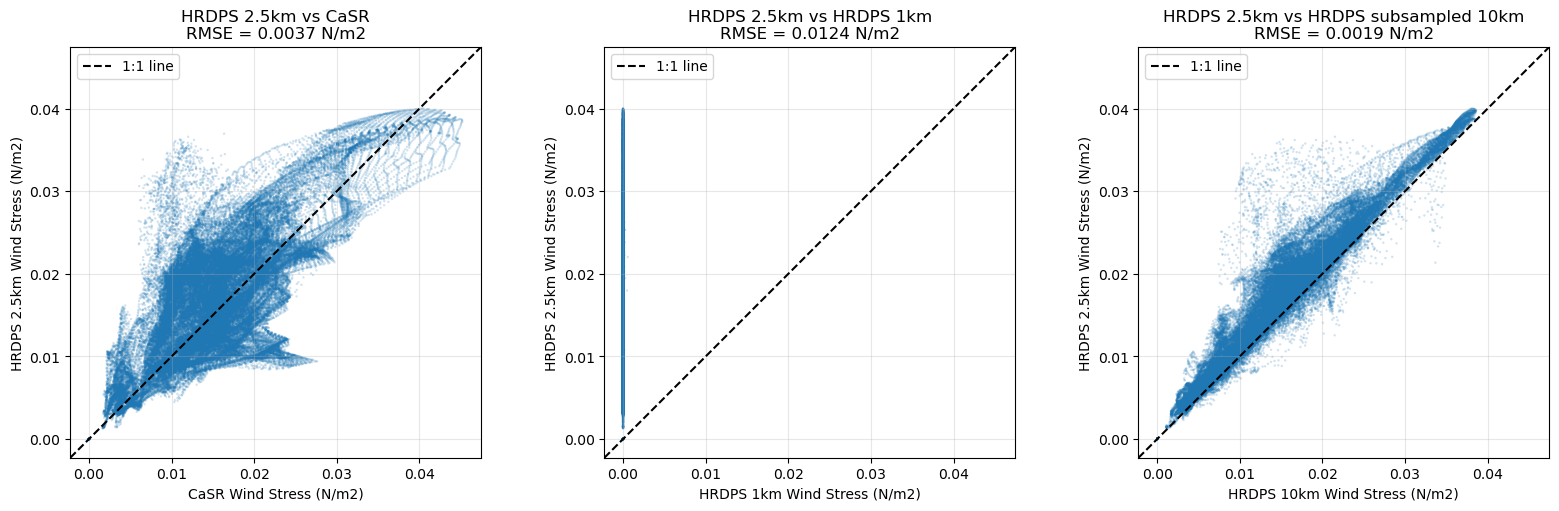

In [14]:
# Visualize
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    1,3,
    figsize=(16, 5),
    constrained_layout=True
)

# value range 

lower = min(
    np.nanmin(ws_CaSR),
    np.nanmin(ws_HRDPS1),
    np.nanmin(ws_HRDPS25),
    np.nanmin(ws_HRDPS10),
)

upper = max(
    np.nanmax(ws_CaSR),
    np.nanmax(ws_HRDPS1),
    np.nanmax(ws_HRDPS25),
    np.nanmax(ws_HRDPS10),
)

# add some extra space
padding = 0.05 * (upper - lower)

if padding == 0:
    padding = 0.5

lower -= padding
upper += padding

# visualize
# -----------------------------
# CaSR
axes[0].scatter(
    ws_CaSR,
    ws_HRDPS25,
    s=3,
    alpha=0.2,
    edgecolors="none"
)

# reference line
axes[0].plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    color="k",
    label="1:1 line"
)

axes[0].set_xlim(lower, upper)
axes[0].set_ylim(lower, upper)
axes[0].set_aspect("equal", adjustable="box")

axes[0].set_xlabel("CaSR Wind Stress (N/m2)")
axes[0].set_ylabel("HRDPS 2.5km Wind Stress (N/m2)")

axes[0].set_title(
        "HRDPS 2.5km vs CaSR\n"
        f"RMSE = {rmse_CaSR:.4f} N/m2"
    )

axes[0].grid(alpha=0.3)
axes[0].legend()

# --------------------------

# visualize
# -----------------------------
# HRDPS 1km
axes[1].scatter(
    ws_HRDPS1,
    ws_HRDPS25,
    s=3,
    alpha=0.2,
    edgecolors="none"
)

# reference line
axes[1].plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    color="k",
    label="1:1 line"
)

axes[1].set_xlim(lower, upper)
axes[1].set_ylim(lower, upper)
axes[1].set_aspect("equal", adjustable="box")

axes[1].set_xlabel("HRDPS 1km Wind Stress (N/m2)")
axes[1].set_ylabel("HRDPS 2.5km Wind Stress (N/m2)")

axes[1].set_title(
        "HRDPS 2.5km vs HRDPS 1km\n"
        f"RMSE = {rmse_HRDPS1:.4f} N/m2"
    )

axes[1].grid(alpha=0.3)
axes[1].legend()

# --------------------------

# visualize
# -----------------------------
# HRDPS 10km
axes[2].scatter(
    ws_HRDPS10,
    ws_HRDPS25,
    s=3,
    alpha=0.2,
    edgecolors="none"
)

# reference line
axes[2].plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    color="k",
    label="1:1 line"
)

axes[2].set_xlim(lower, upper)
axes[2].set_ylim(lower, upper)
axes[2].set_aspect("equal", adjustable="box")

axes[2].set_xlabel("HRDPS 10km Wind Stress (N/m2)")
axes[2].set_ylabel("HRDPS 2.5km Wind Stress (N/m2)")

axes[2].set_title(
        "HRDPS 2.5km vs HRDPS subsampled 10km\n"
        f"RMSE = {rmse_HRDPS10:.4f} N/m2"
    )

axes[2].grid(alpha=0.3)
axes[2].legend()

# --------------------------

plt.show()

In [11]:
print(np.nanmax(ws_HRDPS1))
print(np.nanmin(ws_HRDPS1))


0.00056898495
0.0


**Something is wrong with the HRDPS1 data. Need another look.**

## Flux Field

### Wind Stress Flux

CaSR time      : 2023-03-01T12:00:00.000000000
HRDPS 2.5 time : 2023-03-01T12:00:00.000000000
HRDPS 10 time  : 2023-03-01T12:00:00.000000000
CaSR shape      : (898, 398)
HRDPS 2.5 shape : (898, 398)
HRDPS 10 shape  : (898, 398)

Color ranges:
Wind stress : 0.0000 to 0.0452
Difference  : -0.0273 to 0.0273


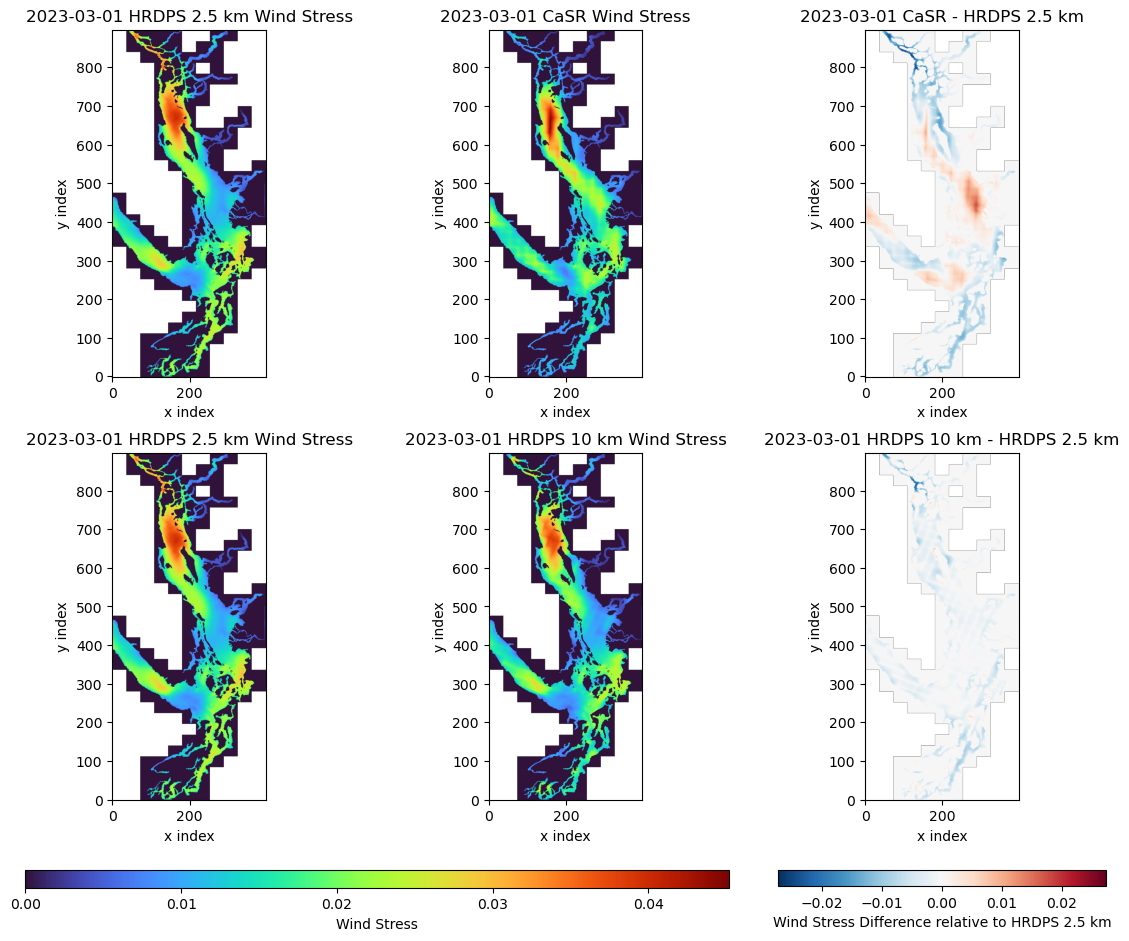

In [1]:
# Wind Stress Flux

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# Paths
# ============================================================

path_CaSR_flux = (
    '/ocean/jqiu/results/Flux/flux_01mar23_CaSR/'
    'SalishSea_1d_20230301_20230301_sbfx_T.nc'
)

path_HRDPS25_flux = (
    '/ocean/jqiu/results/Flux/flux_01mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230301_sbfx_T.nc'
)

path_HRDPS10_flux = (
    '/ocean/jqiu/results/Flux/flux_01mar23_hrdps10/'
    'SalishSea_1d_20230301_20230301_sbfx_T.nc'
)


# ============================================================
# Load datasets
# HRDPS 1 km flux is NOT used
# ============================================================

ds_CaSR_flux = xr.open_dataset(path_CaSR_flux)
ds_HRDPS25_flux = xr.open_dataset(path_HRDPS25_flux)
ds_HRDPS10_flux = xr.open_dataset(path_HRDPS10_flux)


# ============================================================
# Read wind stress
# only one daily time record, so use time_counter = 0
# ============================================================

tidx = 0

casr_tau = ds_CaSR_flux['wind_stress'].isel(
    time_counter=tidx
).values

hrdps25_tau = ds_HRDPS25_flux['wind_stress'].isel(
    time_counter=tidx
).values

hrdps10_tau = ds_HRDPS10_flux['wind_stress'].isel(
    time_counter=tidx
).values


# ============================================================
# Differences
#
# HRDPS 2.5 km is the reference
# positive = dataset has larger wind stress than HRDPS 2.5 km
# ============================================================

diff_casr = casr_tau - hrdps25_tau
diff_hrdps10 = hrdps10_tau - hrdps25_tau


# ============================================================
# Time information
# ============================================================

casr_time = ds_CaSR_flux.time_counter.isel(
    time_counter=tidx
).values

hrdps25_time = ds_HRDPS25_flux.time_counter.isel(
    time_counter=tidx
).values

hrdps10_time = ds_HRDPS10_flux.time_counter.isel(
    time_counter=tidx
).values


print("CaSR time      :", casr_time)
print("HRDPS 2.5 time :", hrdps25_time)
print("HRDPS 10 time  :", hrdps10_time)

print("CaSR shape      :", casr_tau.shape)
print("HRDPS 2.5 shape :", hrdps25_tau.shape)
print("HRDPS 10 shape  :", hrdps10_tau.shape)


# ============================================================
# Unified wind-stress color range
# across all three datasets
# ============================================================

all_tau_values = np.concatenate([
    casr_tau[np.isfinite(casr_tau)],
    hrdps25_tau[np.isfinite(hrdps25_tau)],
    hrdps10_tau[np.isfinite(hrdps10_tau)],
])

tau_vmin = np.nanmin(all_tau_values)
tau_vmax = np.nanmax(all_tau_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================

all_diff_values = np.concatenate([
    diff_casr[np.isfinite(diff_casr)],
    diff_hrdps10[np.isfinite(diff_hrdps10)],
])

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"Wind stress : {tau_vmin:.4f} to {tau_vmax:.4f}")
print(f"Difference  : {-diff_max:.4f} to {diff_max:.4f}")


# ============================================================
# Plot: 2 rows × 3 columns
#
# row 1:
# HRDPS 2.5 km | CaSR | CaSR - HRDPS 2.5 km
#
# row 2:
# HRDPS 2.5 km | HRDPS 10 km | HRDPS 10 km - HRDPS 2.5 km
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 11)
)


# ============================================================
# Row 1: CaSR comparison
# ============================================================

im_tau = axes[0, 0].imshow(
    hrdps25_tau,
    origin='lower',
    cmap='turbo',
    vmin=tau_vmin,
    vmax=tau_vmax,
    aspect='equal'
)

axes[0, 0].set_title(
    '2023-03-01 HRDPS 2.5 km Wind Stress'
)
axes[0, 0].set_xlabel('x index')
axes[0, 0].set_ylabel('y index')


axes[0, 1].imshow(
    casr_tau,
    origin='lower',
    cmap='turbo',
    vmin=tau_vmin,
    vmax=tau_vmax,
    aspect='equal'
)

axes[0, 1].set_title(
    '2023-03-01 CaSR Wind Stress'
)
axes[0, 1].set_xlabel('x index')
axes[0, 1].set_ylabel('y index')


im_diff = axes[0, 2].imshow(
    diff_casr,
    origin='lower',
    cmap='RdBu_r',
    norm=diff_norm,
    aspect='equal'
)

axes[0, 2].set_title(
    '2023-03-01 CaSR - HRDPS 2.5 km'
)
axes[0, 2].set_xlabel('x index')
axes[0, 2].set_ylabel('y index')


# ============================================================
# Row 2: HRDPS 10 km comparison
# ============================================================

axes[1, 0].imshow(
    hrdps25_tau,
    origin='lower',
    cmap='turbo',
    vmin=tau_vmin,
    vmax=tau_vmax,
    aspect='equal'
)

axes[1, 0].set_title(
    '2023-03-01 HRDPS 2.5 km Wind Stress'
)
axes[1, 0].set_xlabel('x index')
axes[1, 0].set_ylabel('y index')


axes[1, 1].imshow(
    hrdps10_tau,
    origin='lower',
    cmap='turbo',
    vmin=tau_vmin,
    vmax=tau_vmax,
    aspect='equal'
)

axes[1, 1].set_title(
    '2023-03-01 HRDPS 10 km Wind Stress'
)
axes[1, 1].set_xlabel('x index')
axes[1, 1].set_ylabel('y index')


axes[1, 2].imshow(
    diff_hrdps10,
    origin='lower',
    cmap='RdBu_r',
    norm=diff_norm,
    aspect='equal'
)

axes[1, 2].set_title(
    '2023-03-01 HRDPS 10 km - HRDPS 2.5 km'
)
axes[1, 2].set_xlabel('x index')
axes[1, 2].set_ylabel('y index')


# ============================================================
# Adjust space
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.93,
    bottom=0.13,
    wspace=0.15,
    hspace=0.22
)


# ============================================================
# Wind stress colorbar
# shared by first two columns
# ============================================================

cbar_tau = fig.colorbar(
    im_tau,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.045,
    pad=0.08,
    aspect=40
)

cbar_tau.set_label('Wind Stress')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================

cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.045,
    pad=0.08,
    aspect=20
)

cbar_diff.set_label(
    'Wind Stress Difference relative to HRDPS 2.5 km'
)


plt.show()


# ============================================================
# Close files
# ============================================================

ds_CaSR_flux.close()
ds_HRDPS25_flux.close()
ds_HRDPS10_flux.close()

## Heat Flux (without solar radiation)

CaSR time      : 2023-03-01T12:00:00.000000000
HRDPS 2.5 time : 2023-03-01T12:00:00.000000000
HRDPS 10 time  : 2023-03-01T12:00:00.000000000
CaSR shape      : (898, 398)
HRDPS 2.5 shape : (898, 398)
HRDPS 10 shape  : (898, 398)

Color ranges:
Heat flux  : -229.59 to 1.18
Difference : -69.73 to 69.73


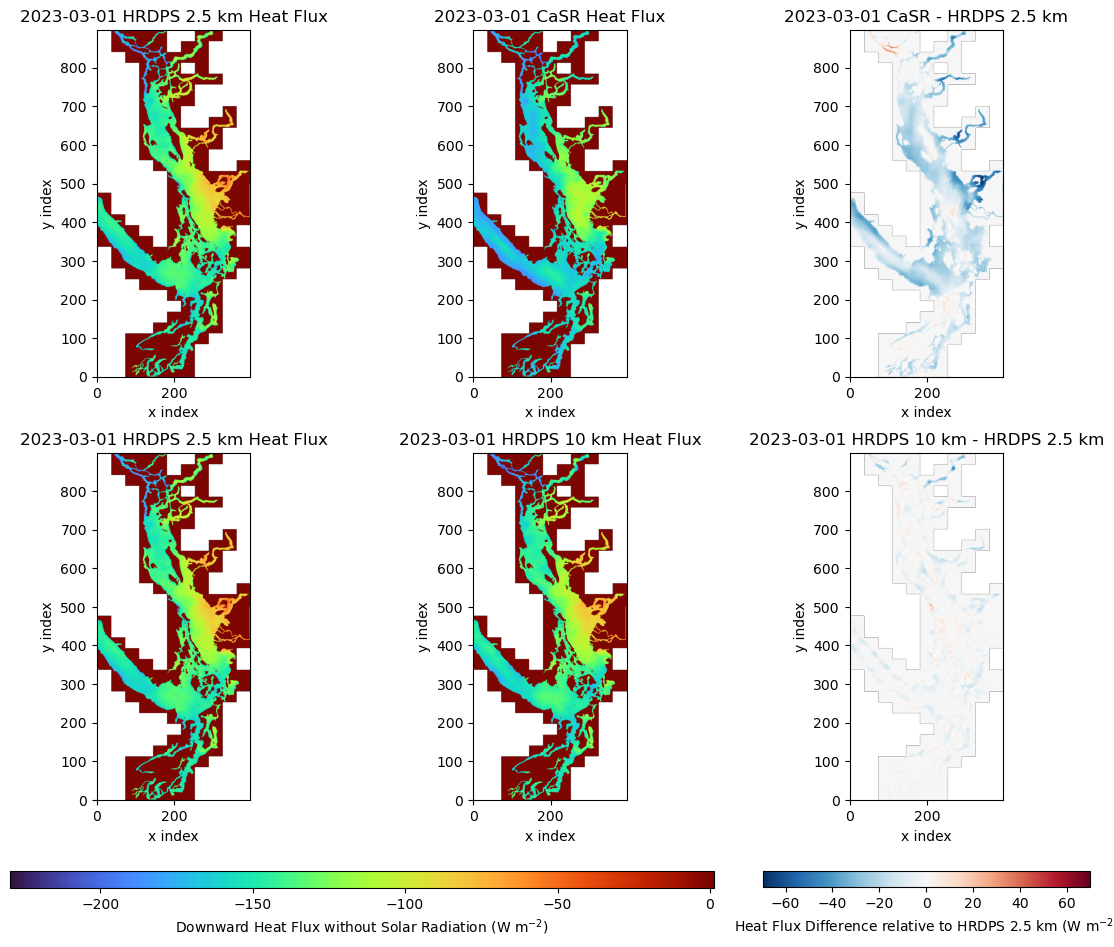

In [3]:
# Heat Flux (without solar radiation)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# Paths
# ============================================================

path_CaSR_flux = (
    '/ocean/jqiu/results/Flux/flux_01mar23_CaSR/'
    'SalishSea_1d_20230301_20230301_sbfx_T.nc'
)

path_HRDPS25_flux = (
    '/ocean/jqiu/results/Flux/flux_01mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230301_sbfx_T.nc'
)

path_HRDPS10_flux = (
    '/ocean/jqiu/results/Flux/flux_01mar23_hrdps10/'
    'SalishSea_1d_20230301_20230301_sbfx_T.nc'
)


# ============================================================
# Load datasets
# HRDPS 1 km flux is NOT used
# ============================================================

ds_CaSR_flux = xr.open_dataset(path_CaSR_flux)
ds_HRDPS25_flux = xr.open_dataset(path_HRDPS25_flux)
ds_HRDPS10_flux = xr.open_dataset(path_HRDPS10_flux)


# ============================================================
# Read heat flux
#
# Solar radiation is not available.
#
# Heat flux here includes:
# longwave + sensible + latent + emp
#
# All components are negative downward.
#
# only one daily time record, so use time_counter = 0
# ============================================================

tidx = 0

casr_heat = (
    ds_CaSR_flux['longwave_heat_flux'].isel(time_counter=tidx)
    + ds_CaSR_flux['sensible_heat_flux'].isel(time_counter=tidx)
    + ds_CaSR_flux['latent_heat_flux'].isel(time_counter=tidx)
    + ds_CaSR_flux['emp_heat_flux'].isel(time_counter=tidx)
).values

hrdps25_heat = (
    ds_HRDPS25_flux['longwave_heat_flux'].isel(time_counter=tidx)
    + ds_HRDPS25_flux['sensible_heat_flux'].isel(time_counter=tidx)
    + ds_HRDPS25_flux['latent_heat_flux'].isel(time_counter=tidx)
    + ds_HRDPS25_flux['emp_heat_flux'].isel(time_counter=tidx)
).values

hrdps10_heat = (
    ds_HRDPS10_flux['longwave_heat_flux'].isel(time_counter=tidx)
    + ds_HRDPS10_flux['sensible_heat_flux'].isel(time_counter=tidx)
    + ds_HRDPS10_flux['latent_heat_flux'].isel(time_counter=tidx)
    + ds_HRDPS10_flux['emp_heat_flux'].isel(time_counter=tidx)
).values


# ============================================================
# Differences
#
# HRDPS 2.5 km is the reference
#
# positive = dataset has less downward heat flux
# negative = dataset has more downward heat flux
# ============================================================

diff_casr = casr_heat - hrdps25_heat
diff_hrdps10 = hrdps10_heat - hrdps25_heat


# ============================================================
# Time information
# ============================================================

casr_time = ds_CaSR_flux.time_counter.isel(
    time_counter=tidx
).values

hrdps25_time = ds_HRDPS25_flux.time_counter.isel(
    time_counter=tidx
).values

hrdps10_time = ds_HRDPS10_flux.time_counter.isel(
    time_counter=tidx
).values


print("CaSR time      :", casr_time)
print("HRDPS 2.5 time :", hrdps25_time)
print("HRDPS 10 time  :", hrdps10_time)

print("CaSR shape      :", casr_heat.shape)
print("HRDPS 2.5 shape :", hrdps25_heat.shape)
print("HRDPS 10 shape  :", hrdps10_heat.shape)


# ============================================================
# Unified heat-flux color range
# across all three datasets
# ============================================================

all_heat_values = np.concatenate([
    casr_heat[np.isfinite(casr_heat)],
    hrdps25_heat[np.isfinite(hrdps25_heat)],
    hrdps10_heat[np.isfinite(hrdps10_heat)],
])

heat_vmin = np.nanmin(all_heat_values)
heat_vmax = np.nanmax(all_heat_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================

all_diff_values = np.concatenate([
    diff_casr[np.isfinite(diff_casr)],
    diff_hrdps10[np.isfinite(diff_hrdps10)],
])

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"Heat flux  : {heat_vmin:.2f} to {heat_vmax:.2f}")
print(f"Difference : {-diff_max:.2f} to {diff_max:.2f}")


# ============================================================
# Plot: 2 rows × 3 columns
#
# row 1:
# HRDPS 2.5 km | CaSR | CaSR - HRDPS 2.5 km
#
# row 2:
# HRDPS 2.5 km | HRDPS 10 km | HRDPS 10 km - HRDPS 2.5 km
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 11)
)


# ============================================================
# Row 1: CaSR comparison
# ============================================================

im_heat = axes[0, 0].imshow(
    hrdps25_heat,
    origin='lower',
    cmap='turbo',
    vmin=heat_vmin,
    vmax=heat_vmax,
    aspect='equal'
)

axes[0, 0].set_title(
    '2023-03-01 HRDPS 2.5 km Heat Flux'
)

axes[0, 0].set_xlabel('x index')
axes[0, 0].set_ylabel('y index')


axes[0, 1].imshow(
    casr_heat,
    origin='lower',
    cmap='turbo',
    vmin=heat_vmin,
    vmax=heat_vmax,
    aspect='equal'
)

axes[0, 1].set_title(
    '2023-03-01 CaSR Heat Flux'
)

axes[0, 1].set_xlabel('x index')
axes[0, 1].set_ylabel('y index')


im_diff = axes[0, 2].imshow(
    diff_casr,
    origin='lower',
    cmap='RdBu_r',
    norm=diff_norm,
    aspect='equal'
)

axes[0, 2].set_title(
    '2023-03-01 CaSR - HRDPS 2.5 km'
)

axes[0, 2].set_xlabel('x index')
axes[0, 2].set_ylabel('y index')


# ============================================================
# Row 2: HRDPS 10 km comparison
# ============================================================

axes[1, 0].imshow(
    hrdps25_heat,
    origin='lower',
    cmap='turbo',
    vmin=heat_vmin,
    vmax=heat_vmax,
    aspect='equal'
)

axes[1, 0].set_title(
    '2023-03-01 HRDPS 2.5 km Heat Flux'
)

axes[1, 0].set_xlabel('x index')
axes[1, 0].set_ylabel('y index')


axes[1, 1].imshow(
    hrdps10_heat,
    origin='lower',
    cmap='turbo',
    vmin=heat_vmin,
    vmax=heat_vmax,
    aspect='equal'
)

axes[1, 1].set_title(
    '2023-03-01 HRDPS 10 km Heat Flux'
)

axes[1, 1].set_xlabel('x index')
axes[1, 1].set_ylabel('y index')


axes[1, 2].imshow(
    diff_hrdps10,
    origin='lower',
    cmap='RdBu_r',
    norm=diff_norm,
    aspect='equal'
)

axes[1, 2].set_title(
    '2023-03-01 HRDPS 10 km - HRDPS 2.5 km'
)

axes[1, 2].set_xlabel('x index')
axes[1, 2].set_ylabel('y index')


# ============================================================
# Adjust space
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.93,
    bottom=0.13,
    wspace=0.15,
    hspace=0.22
)


# ============================================================
# Heat flux colorbar
# shared by first two columns
# ============================================================

cbar_heat = fig.colorbar(
    im_heat,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.045,
    pad=0.08,
    aspect=40
)

cbar_heat.set_label(
    'Downward Heat Flux without Solar Radiation (W m$^{-2}$)'
)


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================

cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.045,
    pad=0.08,
    aspect=20
)

cbar_diff.set_label(
    'Heat Flux Difference relative to HRDPS 2.5 km '
    '(W m$^{-2}$)'
)


plt.show()


# ============================================================
# Close files
# ============================================================

ds_CaSR_flux.close()
ds_HRDPS25_flux.close()
ds_HRDPS10_flux.close()